# INTERACTION BETWEEN FACTORS AND DEFECTS IN SEWER SYSTEMS

# 1. Data preparation

## Load data from Excel

In [2]:
# Import the function that loads multiple sheets from an Excel file
from Load_Excel import load_multiple_sheets

# =============================================================================
# Load selected sheets from the Excel file into a dictionary of DataFrames
# -----------------------------------------------------------------------------
# - The user specifies which sheets to load by providing their names in the
#   'sheet_names' list.
# - Each sheet in the list must exist in the Excel file.
# =============================================================================
from pathlib import Path

base_dir = Path.cwd()


validated_path = (
    base_dir
    / ".."
    / "2.Data_validation"
    / "Validation_rules"
    / "Validated_data.xlsx"
).resolve()

df_information = load_multiple_sheets(
    validated_path,
    sheet_names=["PIPES", "CCTV", "DEFECTS", "HYDRAULIC_PROPERTIES"]
)

# =============================================================================
# Extract each sheet into separate DataFrames for convenience
# -----------------------------------------------------------------------------
# These names (df_pipes, df_cctv, df_defects, df_hydraulic) are optional and
# depend on the user’s workflow. The user can assign any DataFrame they need
# using the keys returned in df_information.
# =============================================================================

df_pipes = df_information["PIPES"]
print(f"Loaded {len(df_pipes)} rows from 'PIPES'.")

df_cctv = df_information["CCTV"]
print(f"Loaded {len(df_cctv)} rows from 'CCTV'.")

df_defects = df_information["DEFECTS"]
print(f"Loaded {len(df_defects)} rows from 'DEFECTS'.")

df_hydraulic = df_information["HYDRAULIC_PROPERTIES"]
print(f"Loaded {len(df_hydraulic)} rows from 'HYDRAULIC_PROPERTIES'.")


Loaded 226863 rows from 'PIPES'.
Loaded 7617 rows from 'CCTV'.
Loaded 46447 rows from 'DEFECTS'.
Loaded 226863 rows from 'HYDRAULIC_PROPERTIES'.


## Add the hydraulic information to the pipes

In [5]:
from Data_Preparation import merge_df_pipes_hydraulic, standardize

# Merges hydraulic data (flow, velocity) into the main pipes table
df_pipes = merge_df_pipes_hydraulic(df_pipes, df_hydraulic)

# Standardize category names
df_pipes=standardize(df_pipes)

## Select the pipe materials and factors to analyse

In [6]:
from Config import *
# ========================= USER EDITABLE SECTION START =========================

# Select the materials to analyse and set their colors
selected_materials = DEFAULT_MATERIALS
colors_material = build_material_color_map(selected_materials)

# Select the factors to analyse
factors = DEFAULT_FACTORS

# Design factors
factors_design_num = FACTORS_DESIGN_NUM
factors_design_cat = FACTORS_DESIGN_CAT

# Environmental factors
factors_envi_num= FACTORS_ENVI_NUM
factors_envi_cat = FACTORS_ENVI_CAT

# Minimum number of observations required for each analysis
min_observations_per_group = DEFAULT_MIN_OBSERVATIONS_PER_GROUP

# Significance threshold for p-values
significant_p_threshold = DEFAULT_SIGNIFICANCE_THRESHOLD

#Define the category labels for the summary table
category_labels =CATEGORY_LABELS

#Set the display names and units of the factors
display_names = DISPLAY_NAMES
units = UNITS

# Set categories colors and order (for categorical factors)
categories_colors = get_categories_colors()
categories_order = get_categories_order()

# ========================== USER EDITABLE SECTION END ==========================

In [7]:
from Data_Preparation import validate_factors_in_dataframe, FactorValidationError

# Validate selected factors
try:
    valid_factors = validate_factors_in_dataframe(
        df_pipes,
        selected_factors=factors,
        strict=False
    )
    print("Valid factors:", valid_factors)

except FactorValidationError as e:
    print("❌ Factor validation error:")
    print(e)

Valid factors: ['Installation_year', 'Diameter', 'Pipe_length', 'Depth', 'Slope', 'Properties', 'Wet_peak_flow_rate', 'Dry_peak_flow_rate', 'Road_num', 'Mean_annual', 'GWL_from_pipe', 'Distance_seawater', 'Liq_vul_num', 'Land_cover_group', 'Land_use_group', 'Sewer_category', 'Soil_type']


In [8]:
from Data_Preparation import auto_classify_factors

# Automatically classify factors as numerical or categorical
factors_num, factors_cat = auto_classify_factors(df_pipes, valid_factors)

print("Final numeric factors:", factors_num)
print("Final categorical factors:", factors_cat)

Final numeric factors: ['Installation_year', 'Diameter', 'Pipe_length', 'Depth', 'Slope', 'Properties', 'Wet_peak_flow_rate', 'Dry_peak_flow_rate', 'Road_num', 'Mean_annual', 'GWL_from_pipe', 'Distance_seawater', 'Liq_vul_num']
Final categorical factors: ['Land_cover_group', 'Land_use_group', 'Sewer_category', 'Soil_type']


In [9]:
from Data_Preparation import filter_by_material, DBReadError, DataPreparationError

# Filter datasets by selected materials
try:
    df_pipes_filtered = filter_by_material(df_pipes, selected_materials)
    print(f"Pipes selected: {len(df_pipes_filtered)} rows.")

except (DBReadError, DataPreparationError) as e:
    print("⚠️ Error during pipe data selection:")
    print(e)

Pipes selected: 219578 rows.


## Remove outliers

In [10]:
from Clean_outliers import clean_outliers_by_material_isoforest_cell

# Remove outliers using Isolation Forest applied separately for each pipe material group
df_pipes_filtered, summary_outliers = clean_outliers_by_material_isoforest_cell(
    df_pipes_filtered,
    numeric_cols=factors_num,
    iso_contamination=0.05,
    cell_mz_thresh=3.5,
    random_state=42,
)

## Merge CCTV and defects data

In [11]:
from Data_Preparation import merge_cctv_defects

df_cctv_filtered,df_defects=merge_cctv_defects (df_cctv,df_pipes_filtered,df_defects)

## Create column with full names for defect types

In [12]:
from Data_Preparation import add_defect_code_full

# Create column
df_defects = add_defect_code_full(df_defects)

## Calculate condition score

In [13]:
from Condition_score_final import calculate_condition_scores

# Calculate condition scores
df_defects, df_cctv_filtered = (
    calculate_condition_scores(
        defects=df_defects,
        cctv=df_cctv_filtered,
        pipes=df_pipes,
    )
)

Missing quantifications to correct: 2345


# 2.Description of dataset

## Boxplots numerical factors

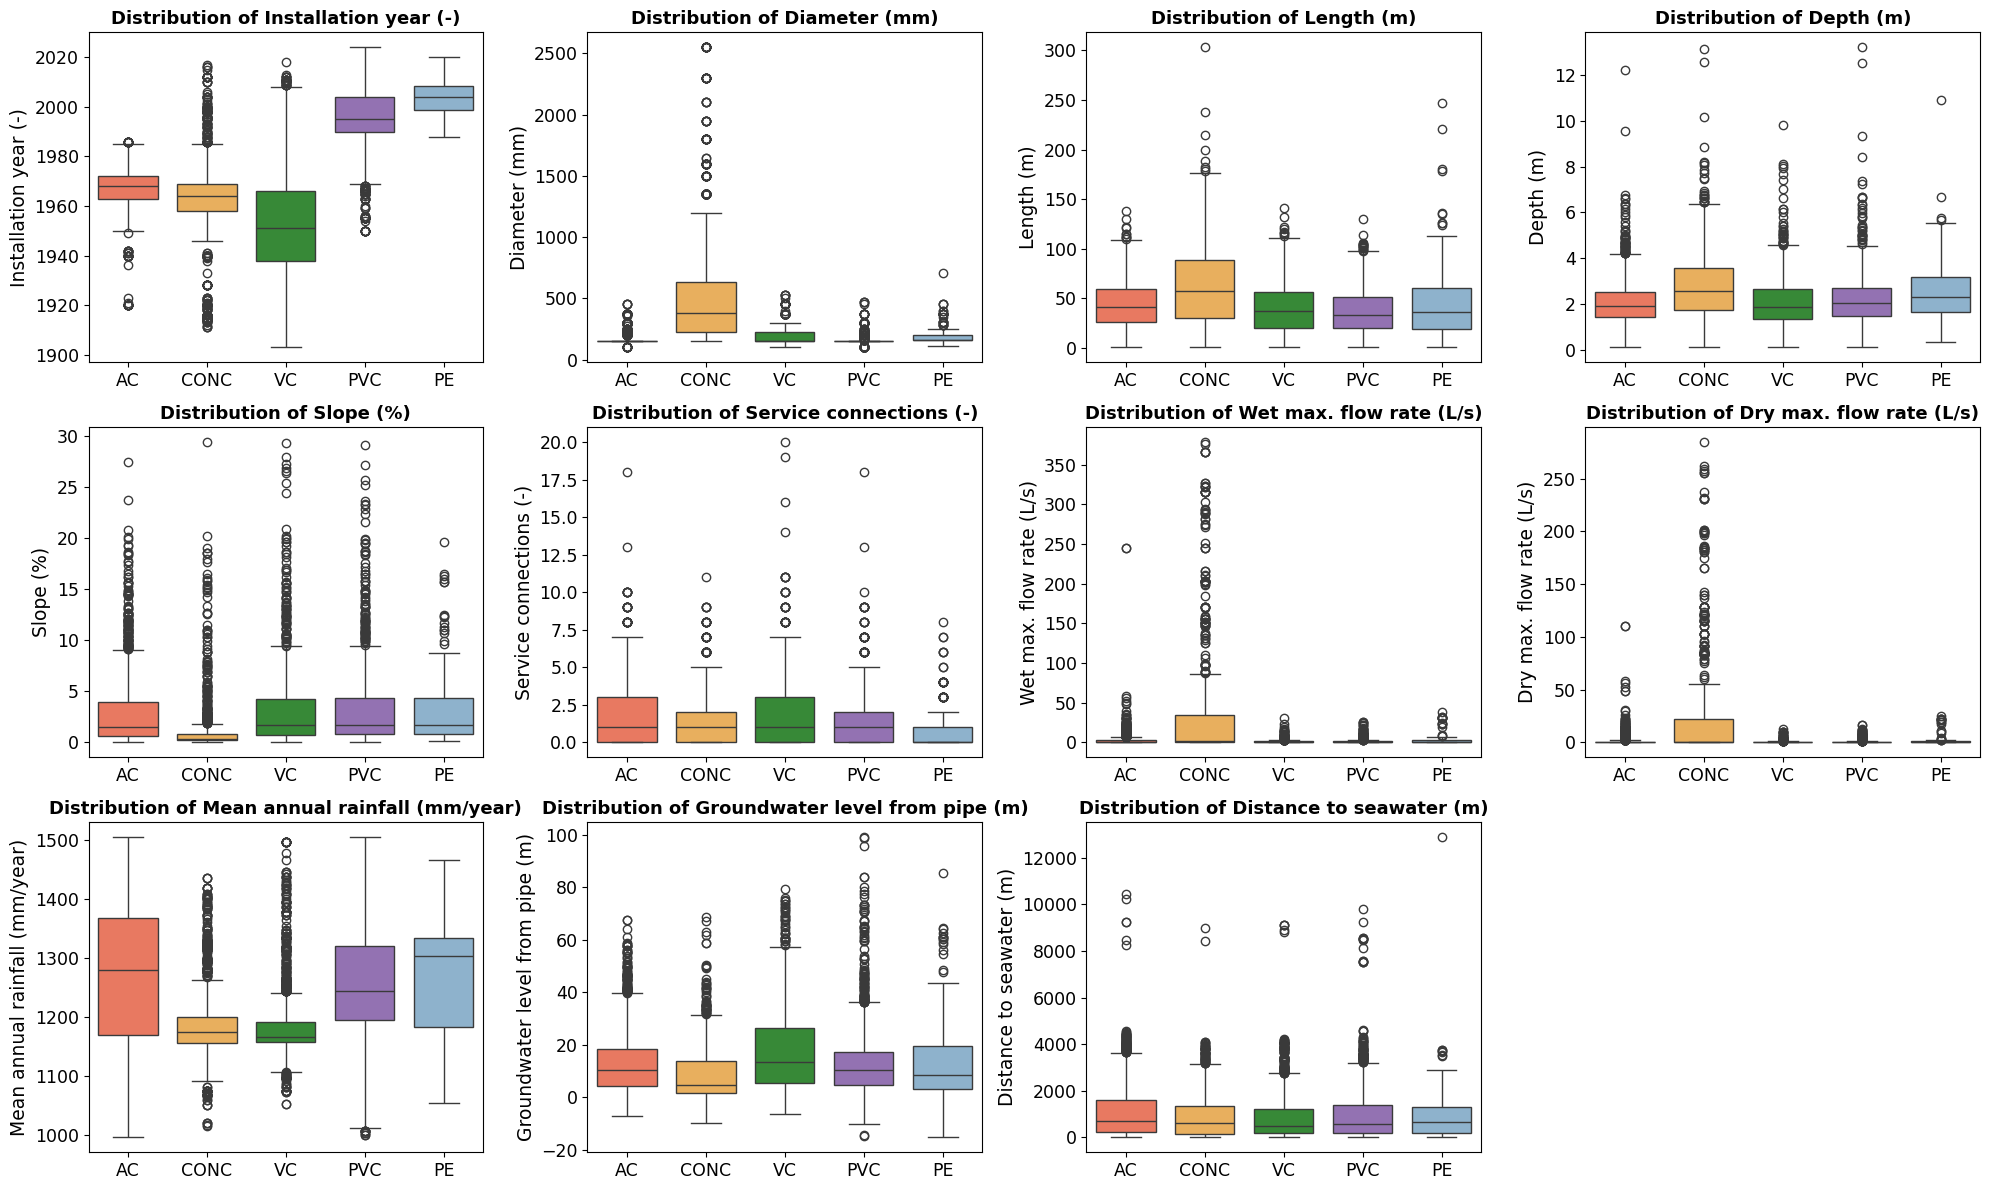

In [14]:
from Description_dataset import plot_boxplots_grid

#Exclude factors from boxplot if desired
excluded_factors = ["Laundries","Restaurants","Road_num", "Liq_vul_num","Traffic_num"]

# Plot boxplots
fig = plot_boxplots_grid(
    df=df_cctv_filtered,
    factors=[f for f in factors_num if f not in excluded_factors],
    display_names=display_names,
    group_col="Material",
    selected_groups=selected_materials,
    colors=colors_material,
    units=units,
    n_cols = 4,
)

# Save as PDF
fig.savefig(
    "Figures/Figure 1.pdf",
    format="pdf",
    bbox_inches="tight"
)

In [15]:
from Description_dataset import create_range_table, create_categorical_summary_table

#Calculate the range of each factor
range_table = create_range_table(
    df=df_cctv_filtered,
    factors=factors_num,
    display_names=display_names
)

range_table

,Factor,Range
0,Installation year,[1903.000–2024.000]
1,Diameter,[100.000–2550.000]
2,Length,[0.830–303.130]
3,Depth,[0.120–13.203]
4,Slope,[0.005–29.364]
5,Service connections,[0.000–20.000]
6,Wet max. flow rate,[0.000–378.018]
7,Dry max. flow rate,[0.000–284.354]
8,Road,[0.000–1.000]
9,Mean annual rainfall,[995.600–1504.100]


In [16]:
#Create a summary of the categorical variables, using a percentage per subcategory.

categorical_summary = create_categorical_summary_table(
    df=df_cctv_filtered,
    categorical_vars=[
        "Road_num",
        "Land_cover_group",
        "Land_use_group",
        "Liq_vul",
        "Soil_type",
        "Sewer_category"
    ],
    material_order=selected_materials,
    display_names=display_names,
    category_labels=category_labels,
    categories_order=categories_order,
    decimals=1
)
categorical_summary.to_csv("Categorical_summary.csv")

## Interdependencies among factors

In [17]:
from Description_dataset import corr_matrix

# Calculate the correlation matrix using Spearman's rank correlation for all numerical factors (The method can be change)
corr_results=corr_matrix(df_cctv_filtered,
                         factors_num,
                         display_names,
                         method='spearman' # or 'pearson'
                         )

In [18]:
from Description_dataset import mutual_info_categorical_vs_all_mixed

# Calculate normalized mutual information between all numerical  and categorical factors
mi_results = mutual_info_categorical_vs_all_mixed(
    df_cctv_filtered,
    numerical=factors_num,
    categorical=factors_cat+["Material"],
    display_names=display_names,
    n_bins= 10,
    n_neighbors = 3,
    random_state = 42
)

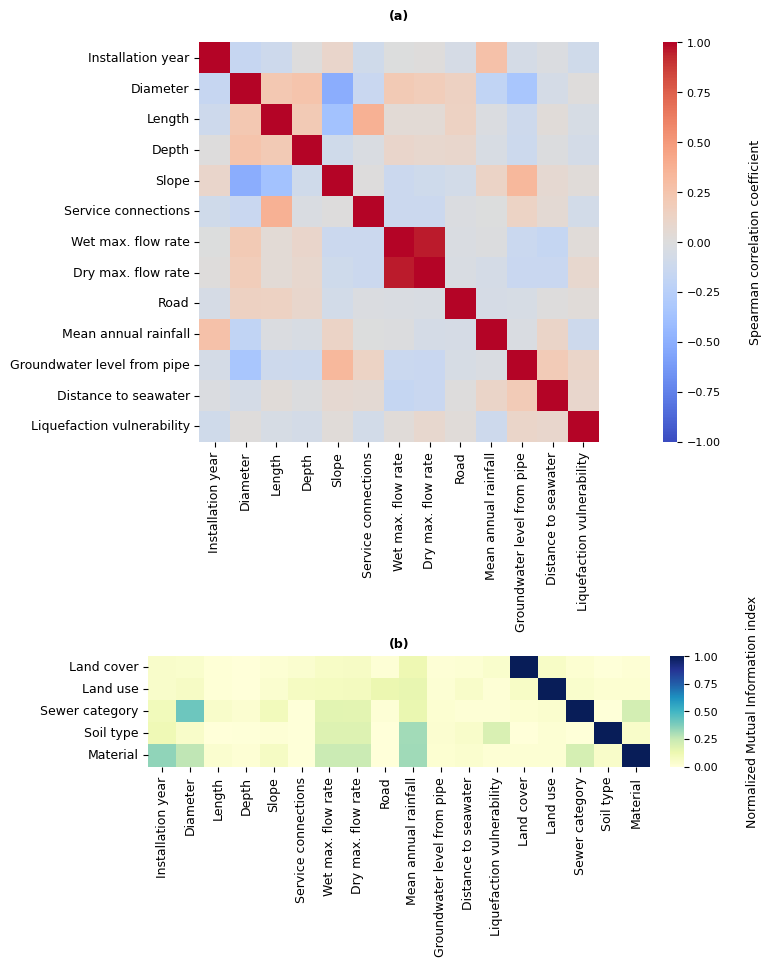

In [19]:
from Description_dataset import plot_corr_and_nmi_panels

# Plot the results for the correlation and mutual information in one graph
fig = plot_corr_and_nmi_panels(
    corr_matrix=corr_results,
    mi_matrix=mi_results)

# Save as PDF
fig.savefig(
    "Figures/Figure 2.pdf",
    format="pdf",
    bbox_inches="tight"
)


# 3. Analysis of numerical factors

## Relationships with condition metrics

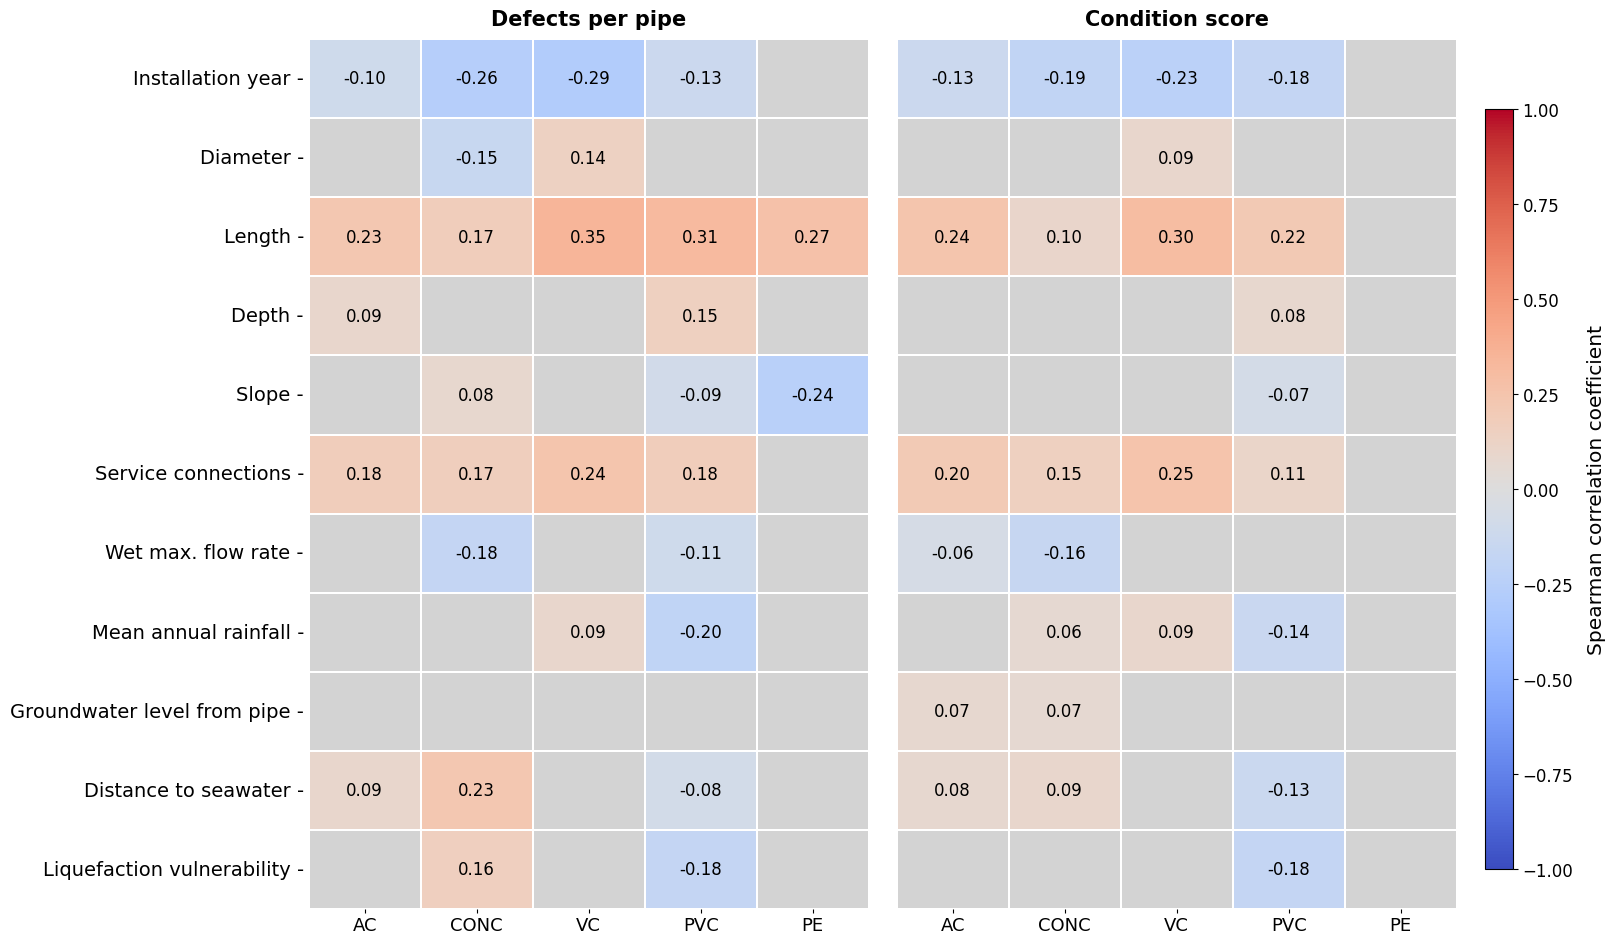

In [20]:
from Analysis_condition_metrics_numerical import plot_multimetric_correlation_heatmaps

# Plot the significant Spearman correlations for three different defect metrics:
# - Defects per pipe
# - Condition score

fig, corr_results = plot_multimetric_correlation_heatmaps(
    df_defect=df_defects,
    df_cctv_filtered=df_cctv_filtered,
    materials=selected_materials,
    factors = [
        f for f in (factors_design_num + factors_envi_num)
        if f not in ['Dry_peak_flow_rate','Road_num']
    ],
    display_names=display_names,
    method='spearman', # or 'pearson'
    p_threshold=significant_p_threshold,
    show_only_significant=True,
    cond_col= 'Structural_condition_grade',
)

# Save as PDF
fig.savefig(
    "Figures/Figure 3.pdf",
    format="pdf",
    bbox_inches="tight"
)

### Linear Analysis with defects per pipe

In [21]:
from Group_factors import create_grouped_variables

# Decimals for the plots with the grouped factors
group_decimals = {
    "Installation_year": 0,
    "Pipe_length": 0,
    "Slope": 3,
    "Depth": 1,
    "Wet_peak_flow_rate": 2,
    "Dry_peak_flow_rate": 2,
    "Mean_annual": 0,
    "Distance_seawater": 0,
    "GWL_from_pipe": 1,
    "Liq_vul_num": 1,
}

#Create grouped factors to plot in linear regression
df_defects_grouped = create_grouped_variables(
    df=df_defects,
    variables=factors_num,
    range_fraction=0.05,
    decimals_mapping=group_decimals,
    suffix="_group"
)

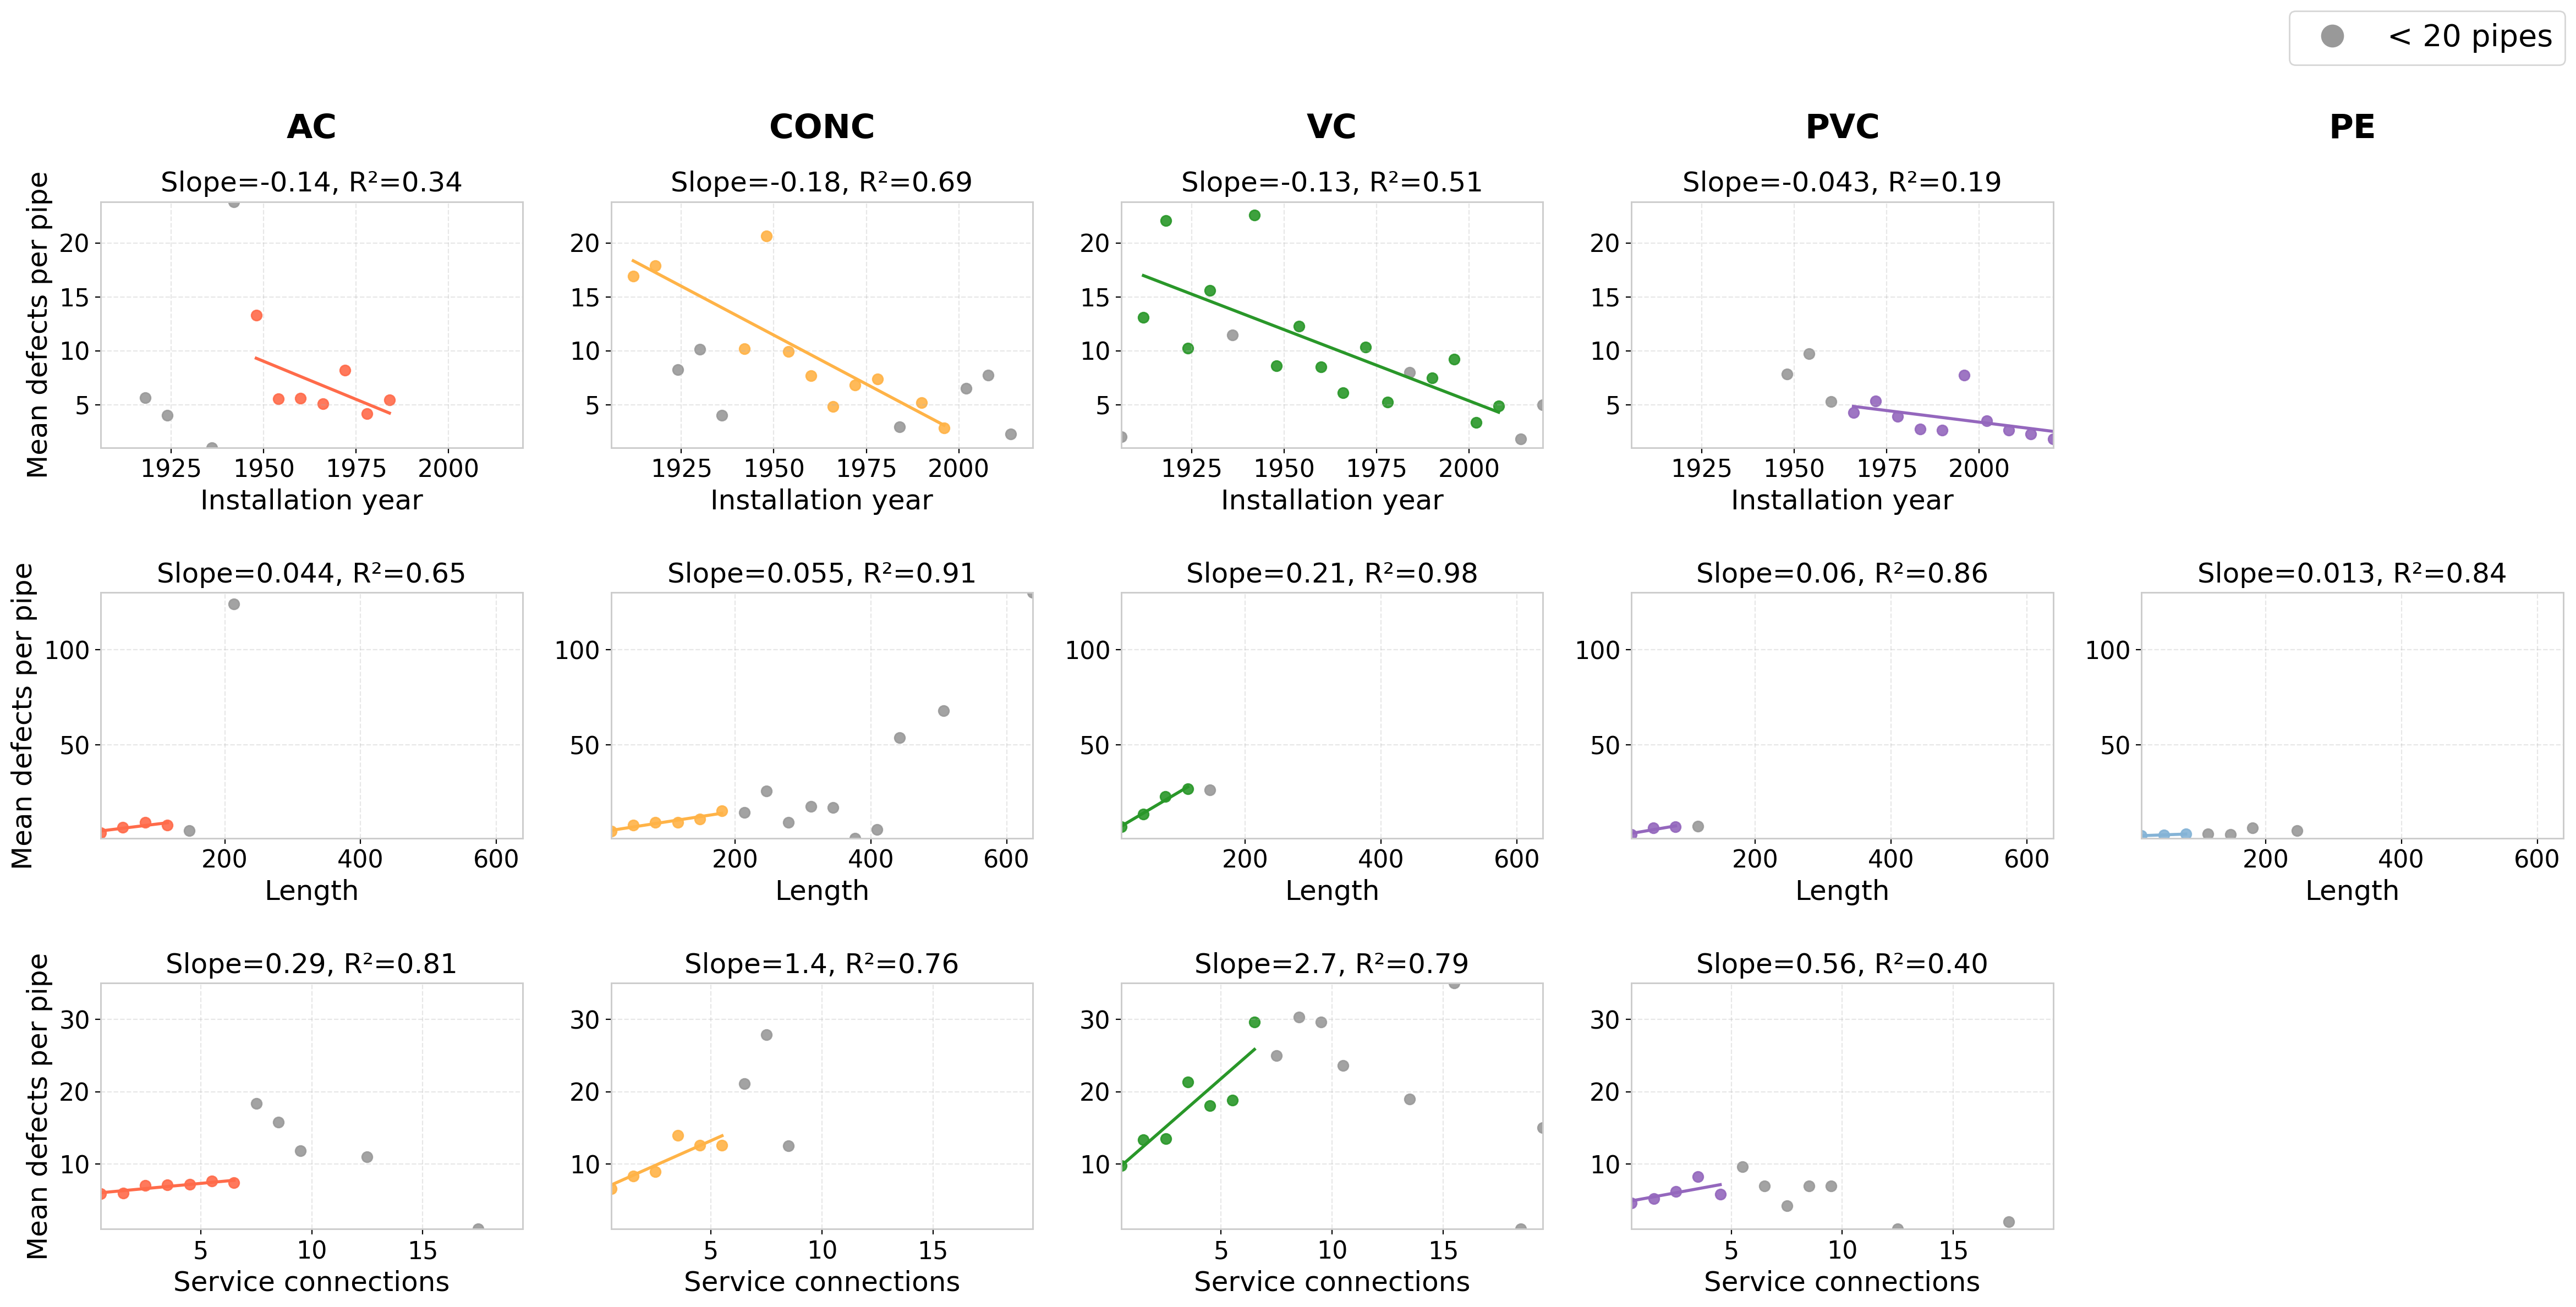

In [22]:
# Computes correlation coefficients between numerical factors and the total number of defects,
# evaluated separately for each pipe material.
from Linear_analysis_defects_per_pipe import plot_topk_total_by_material, correlations_by_material_from_defect_total
excluded_factors = [
    "Liq_vul_num",
    "Traffic",
]

factors_analysis = [
    factor
    for factor in factors
    if factor not in excluded_factors
]

correlation_material_df = correlations_by_material_from_defect_total(
    df=df_defects_grouped,
    factors=factors_analysis,
    id_col='Pipe_ID',
    material_col='Material',
    min_samples=min_observations_per_group,
    method='spearman',
)

# Visualizes the strongest factor–defect relationships per material by plotting the top-ranked
# correlations and their corresponding linear trends.
fig, summary = plot_topk_total_by_material(
    df_grouped=df_defects_grouped,
    corr_df_material=correlation_material_df,
    factors=["Installation_year", "Pipe_length", "Properties"],
    fit_mode="exclude",
    selected_materials=selected_materials,
    materials_order=selected_materials,
    display_names=display_names,
    min_samples=min_observations_per_group
)

#Save as PDF
fig.savefig(
    "Figures/Figure 4.pdf",
    format="pdf",
    bbox_inches="tight"
)

## Relationships with defect types

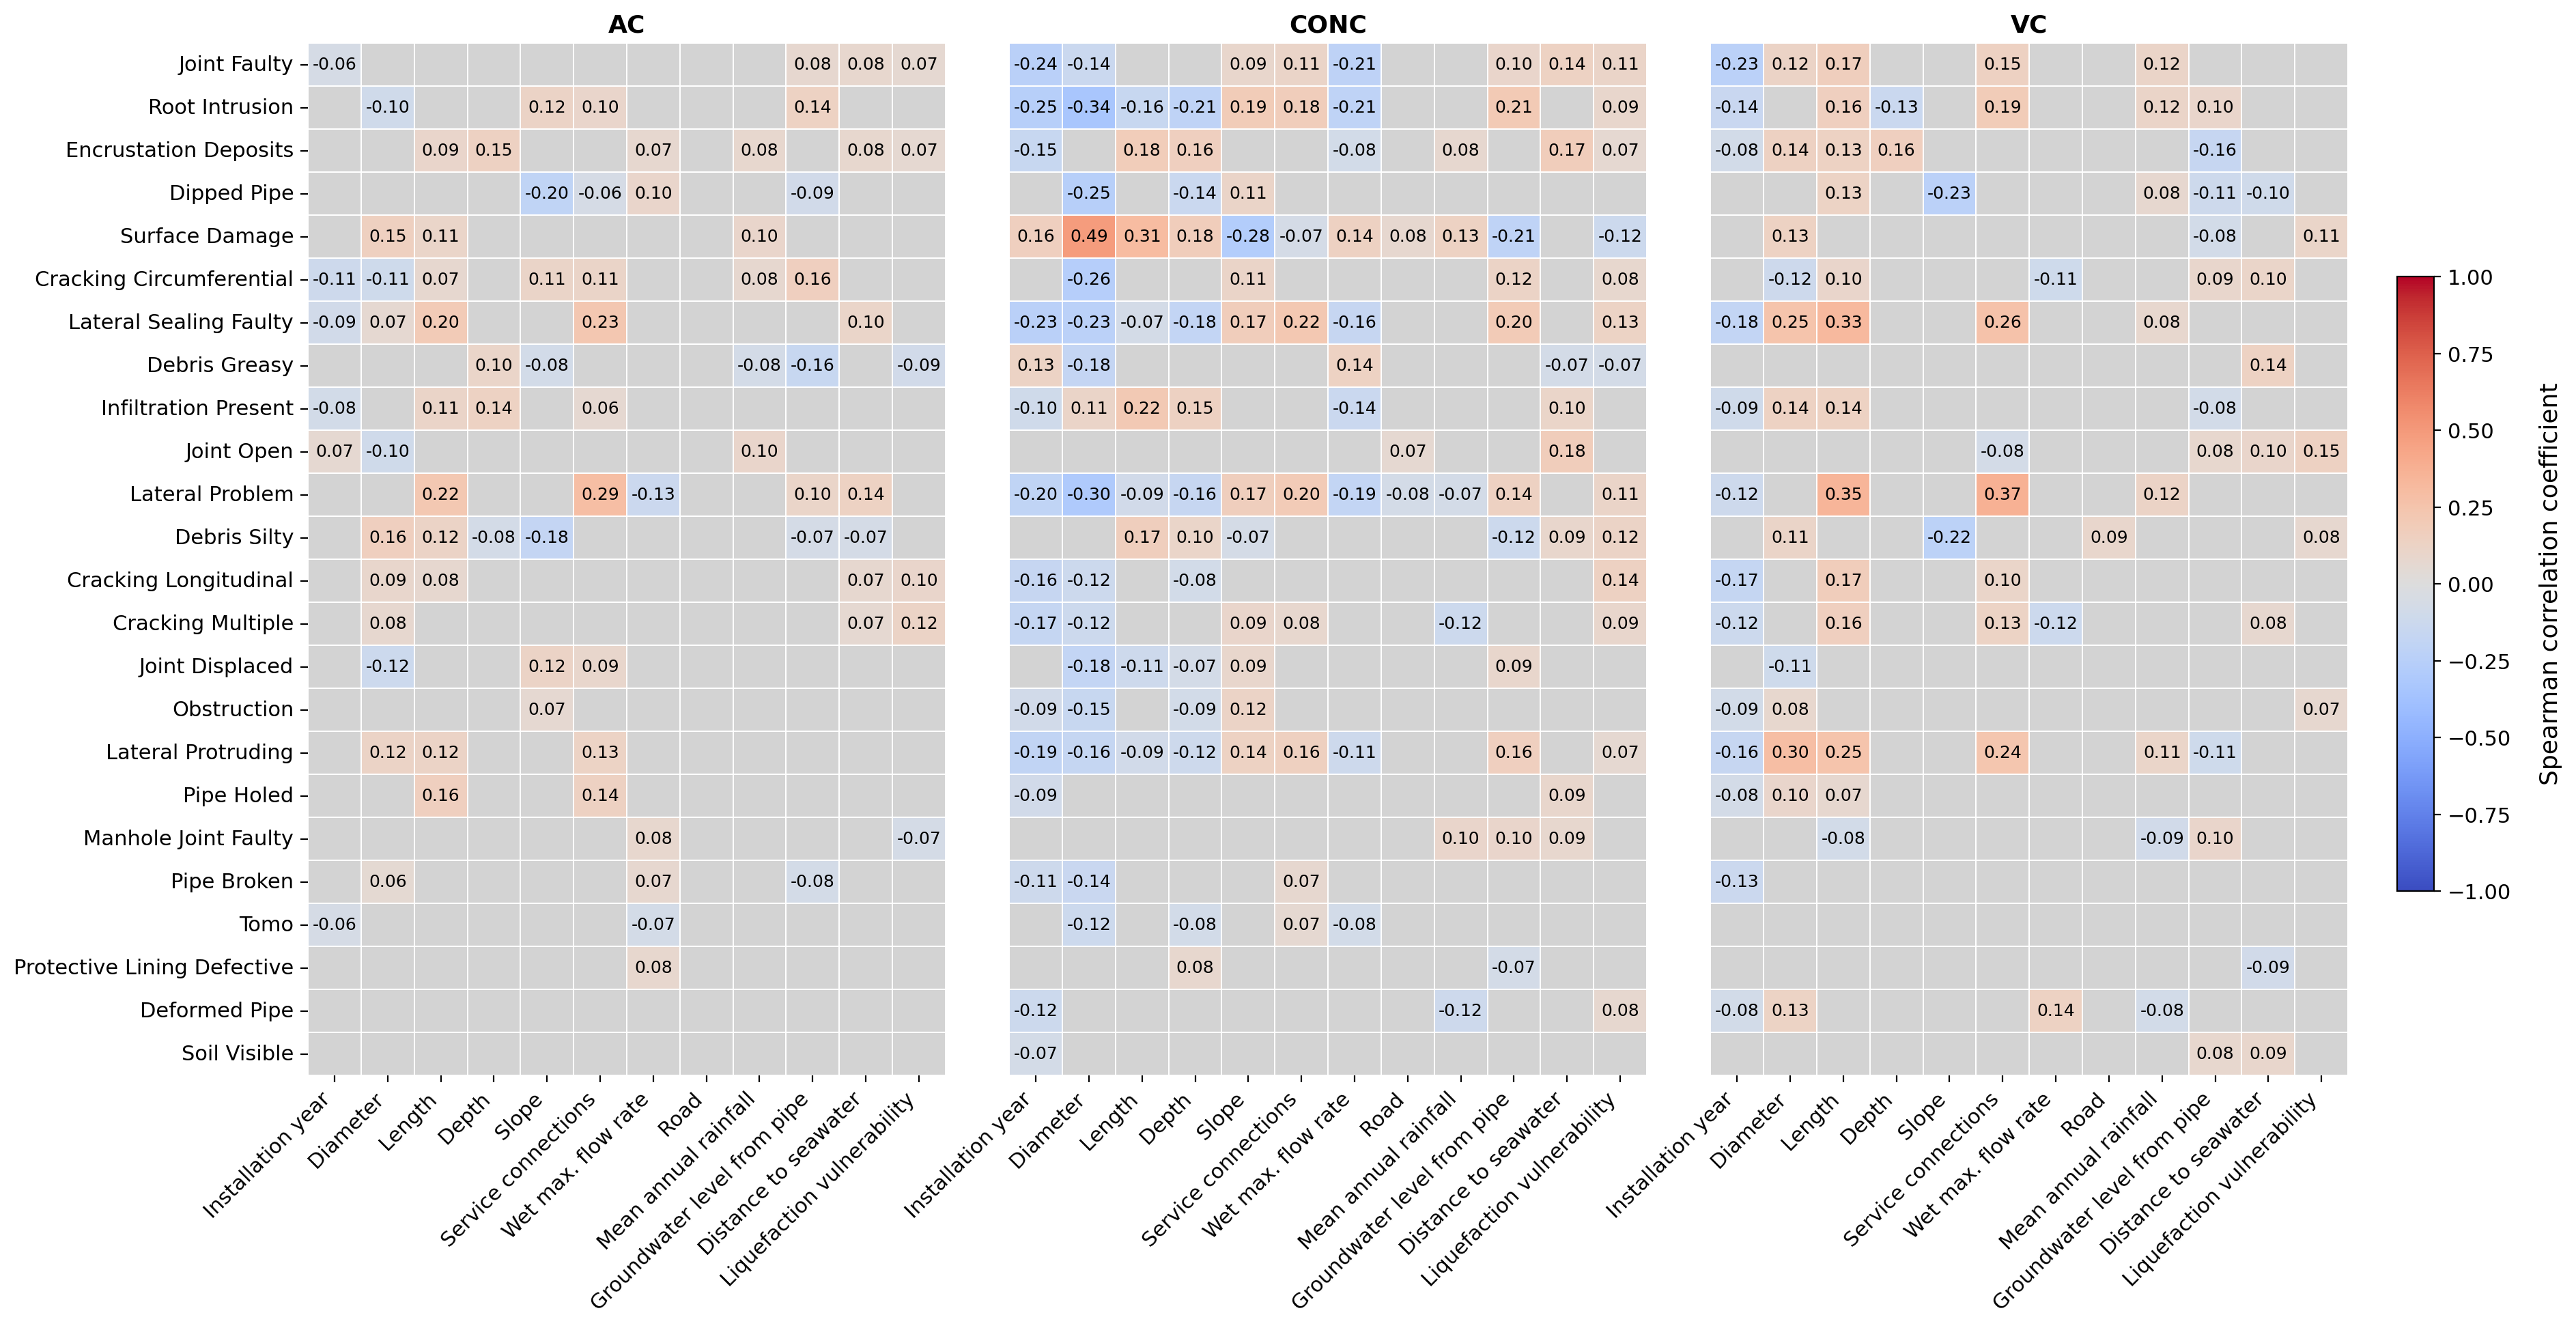

In [23]:
from Analysis_defect_type_numerical import plot_correlation_heatmaps_all_factors

#Plot the correlation analysis of numerical variables and each defect type for each material
fig=plot_correlation_heatmaps_all_factors(
    df_defects,
    factors = [
        f for f in (factors_design_num + factors_envi_num)
        if f not in ['Dry_peak_flow_rate']
    ],
    materials=["AC","CONC","VC"],
    p_threshold=0.05,
    display_names=display_names
)

#Save as PDF
fig.savefig(
    "Figures/Figure 5.pdf",
    format="pdf",
    bbox_inches="tight"
)


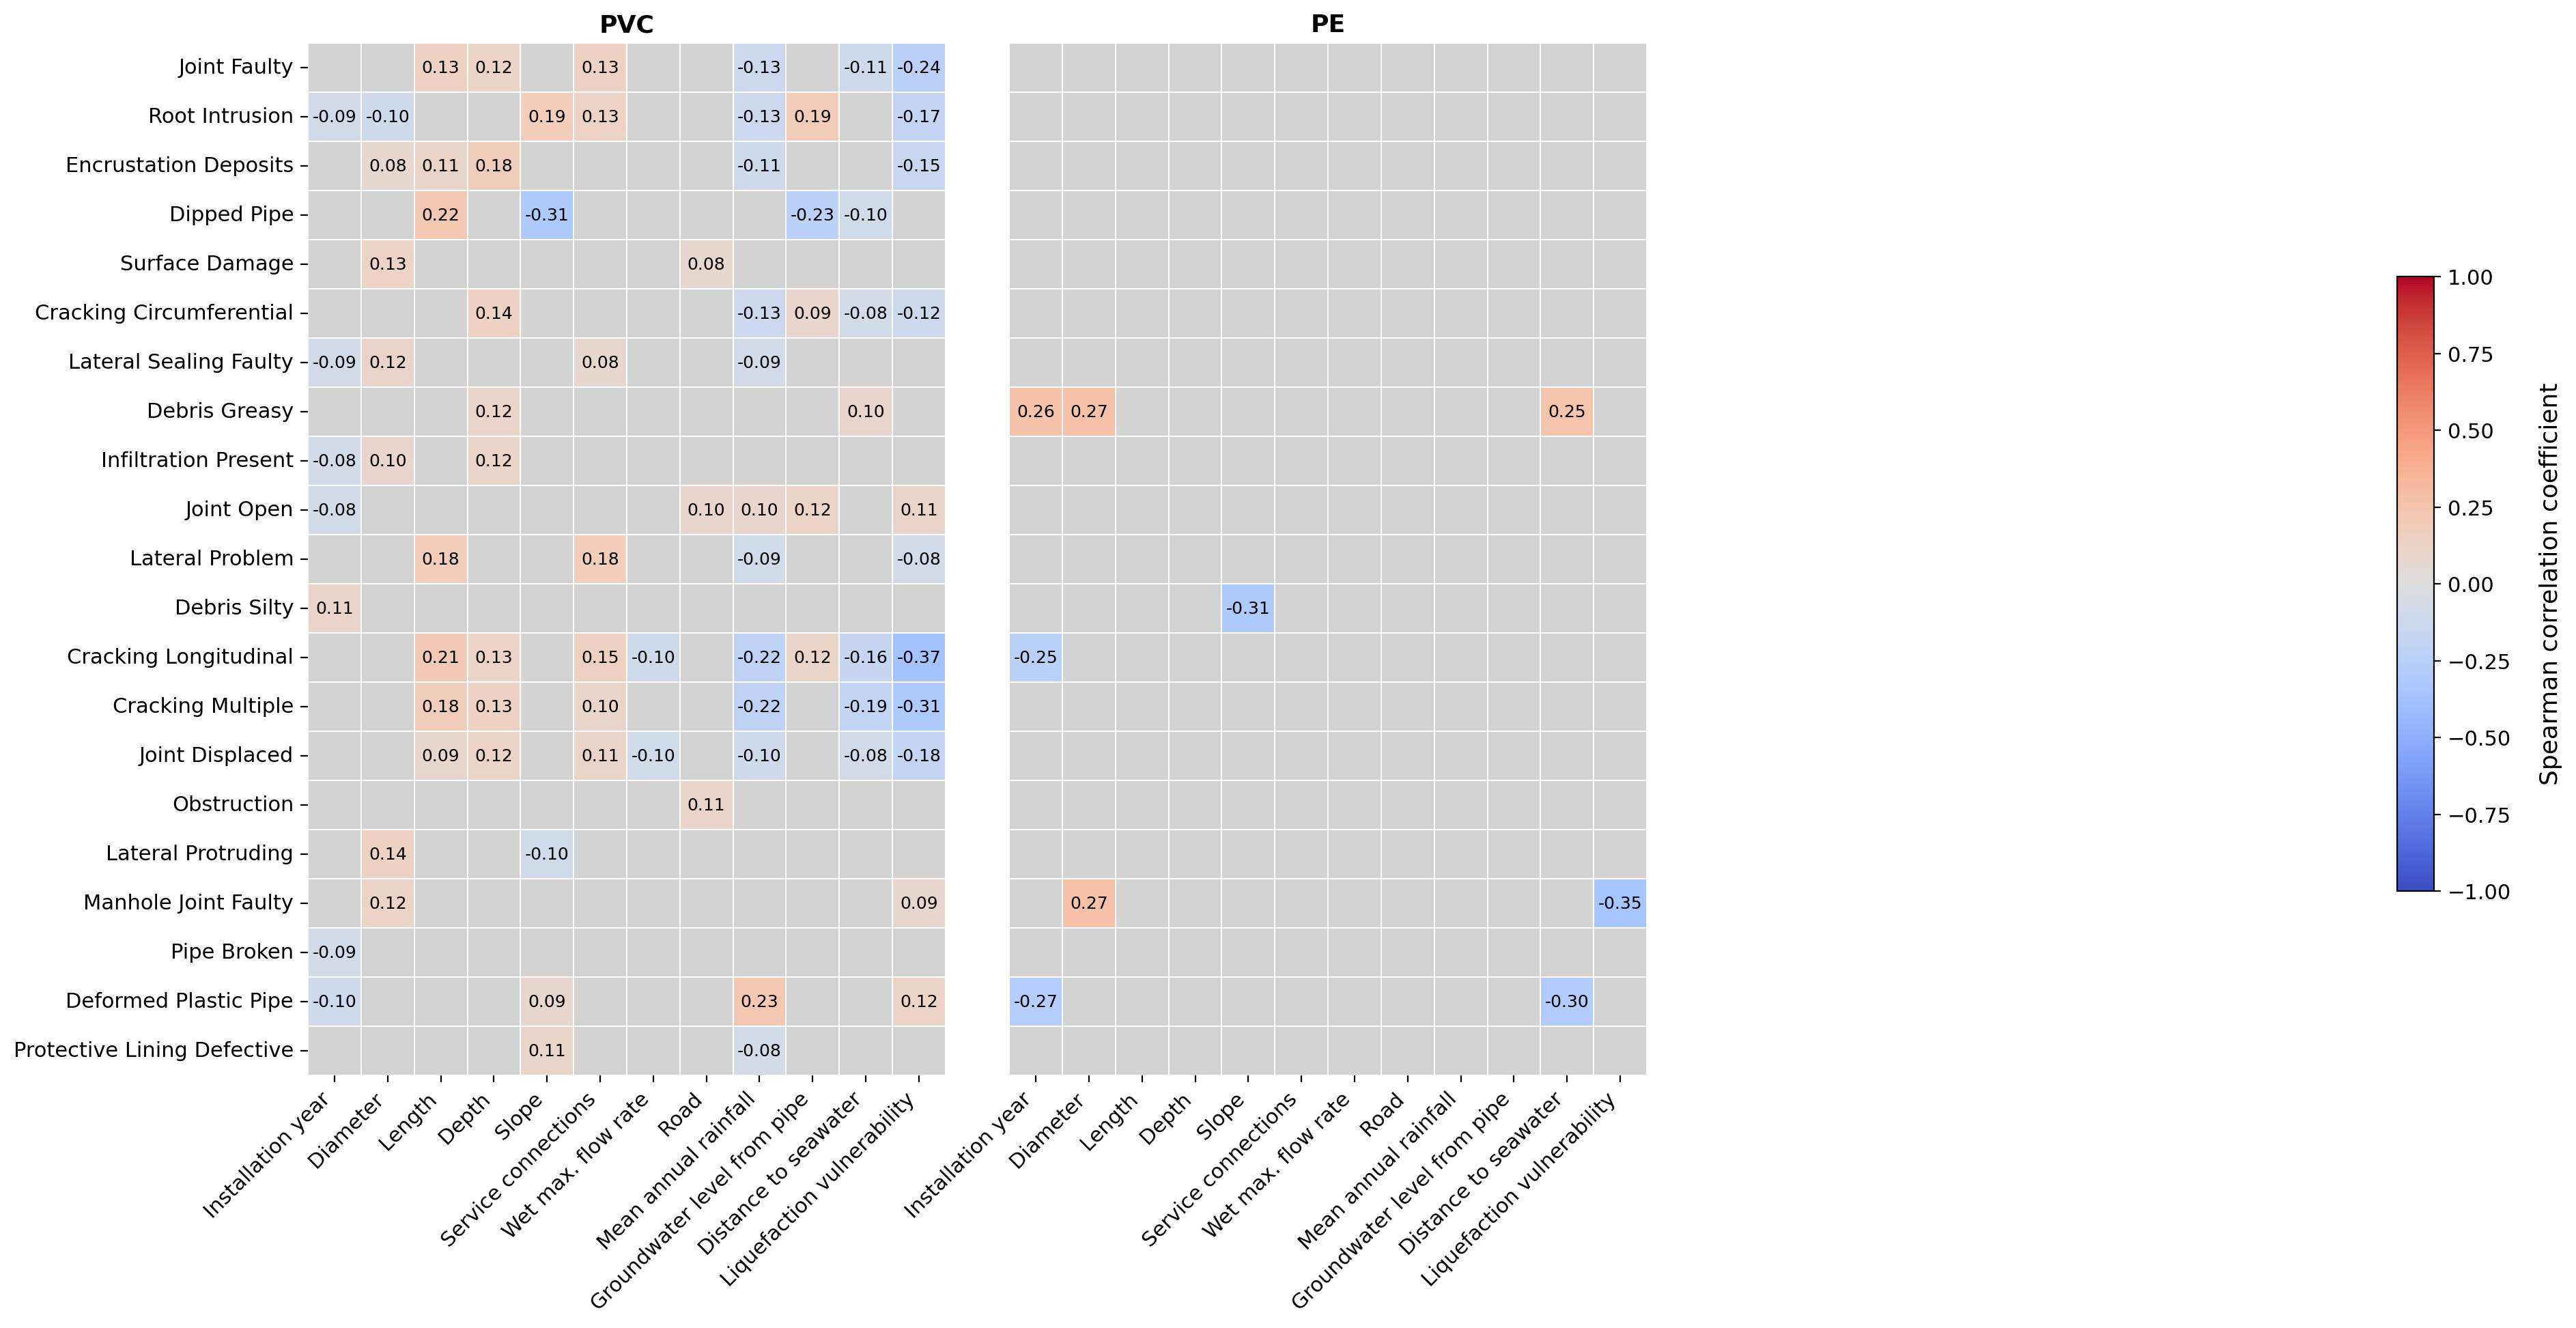

In [24]:
from Analysis_defect_type_numerical import plot_correlation_heatmaps_all_factors

#Plot the correlation analysis of numerical variables and each defect type for each material
fig=plot_correlation_heatmaps_all_factors(
    df_defects,
    factors = [
        f for f in (factors_design_num + factors_envi_num)
        if f not in ['Dry_peak_flow_rate']
    ],
    materials=["PVC","PE"],
    p_threshold=0.05,
    display_names=display_names
)

#Save as PDF
fig.savefig(
    "Figures/Figure 6.pdf",
    format="pdf",
    bbox_inches="tight"
)


### Linear analyses with defect types

In [25]:
from Linear_analysis_defect_type import type_defect_count_vs_factors, build_corr_long_from_mats

corr_all = []
for mat in selected_materials:
    rho_mat, pval_mat, signif_mat, reason_mat, total_occ, pipe_factors, counts_table = type_defect_count_vs_factors(
        df_defects_grouped,
        defect_col='Defect_code_full',
        id_col='Pipe_ID',
        factors=factors_design_num+factors_envi_num,
        min_samples=min_observations_per_group,
        method='spearman',
        material=mat,
        material_col='Material'
    )
    corr_all.append(build_corr_long_from_mats(rho_mat, pval_mat, material=mat))

corr_df = pd.concat(corr_all, ignore_index=True)

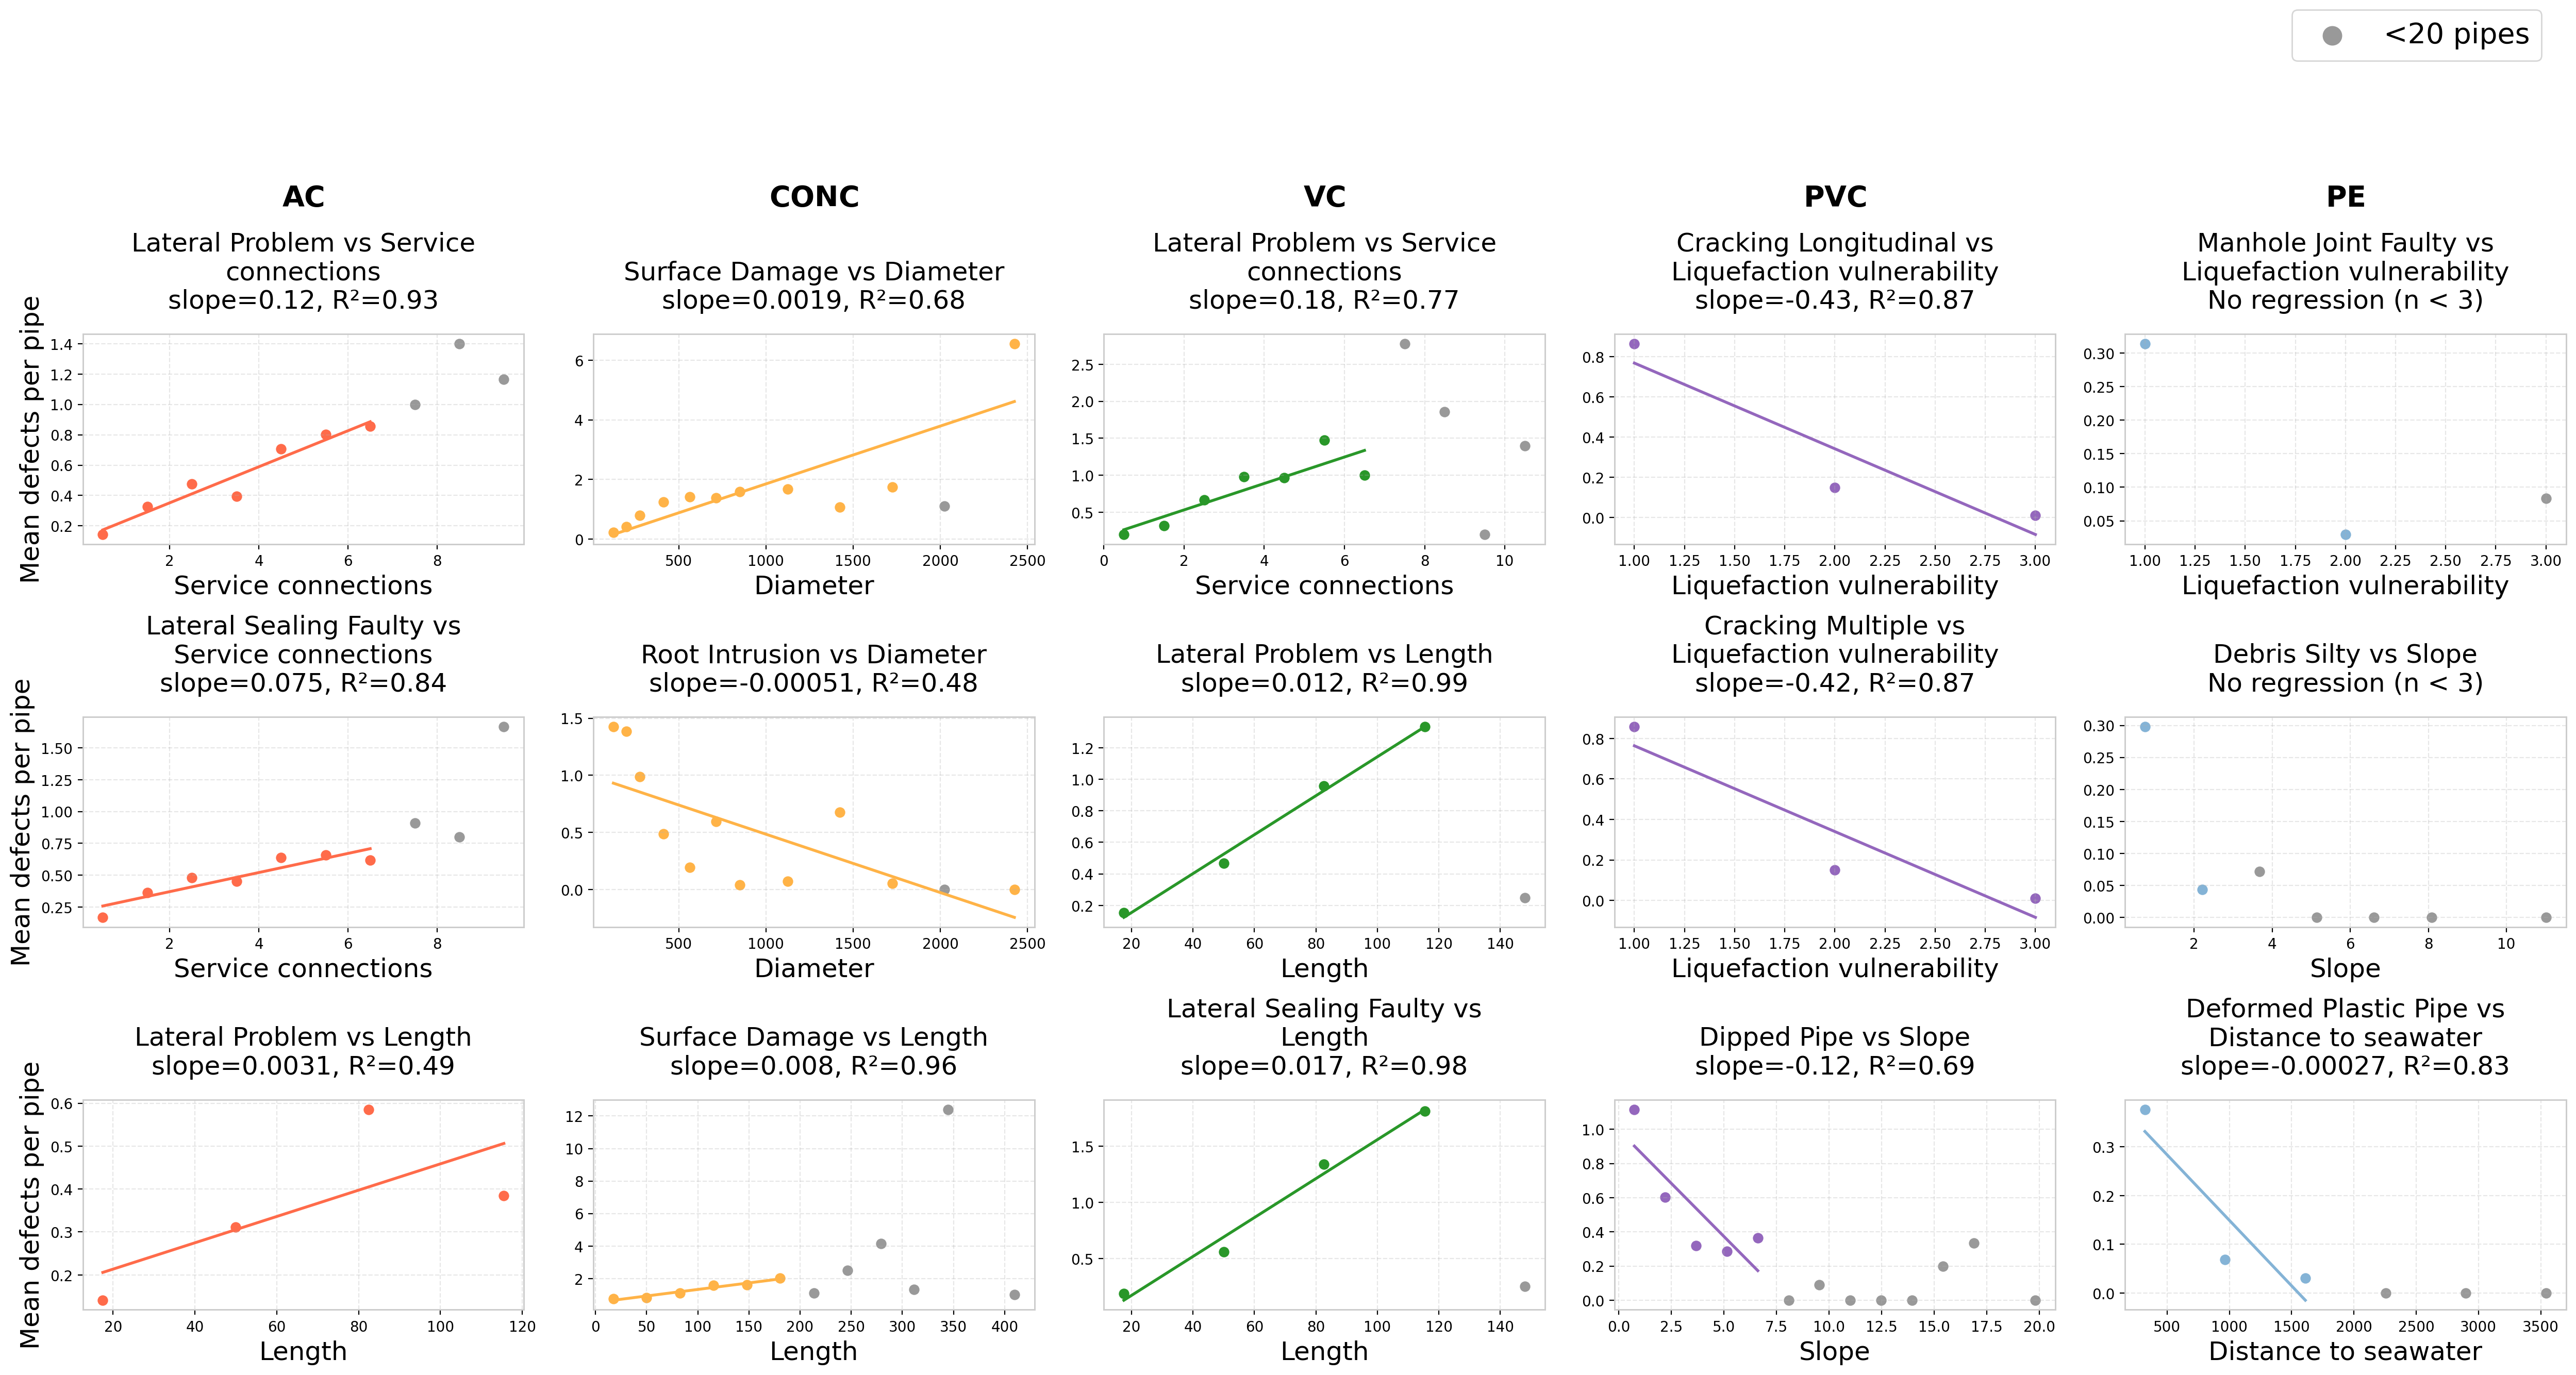

In [26]:
from Linear_analysis_defect_type import plot_top_type_defects
fig = plot_top_type_defects(
    df=df_defects_grouped,
    corr_df=corr_df,
    materials=selected_materials,
    defect_col='Defect_code_full',
    top_k=3,
    p_thr=0.05,
    low_n_threshold=min_observations_per_group,
    min_pipes_per_group=3,
    min_groups_for_fit=3,
    min_groups_to_show=3,
    factor_renamer=display_names,
    cell_size=(5, 4.5),
    color_by_material=True,
    colors_materials=colors_material
)

# Save as PDF
fig.savefig(
    "Figures/Figure 7.pdf",
    format="pdf",
    bbox_inches="tight"
)


# 4. Analysis of categorical defects

## Relationships with condition metrics


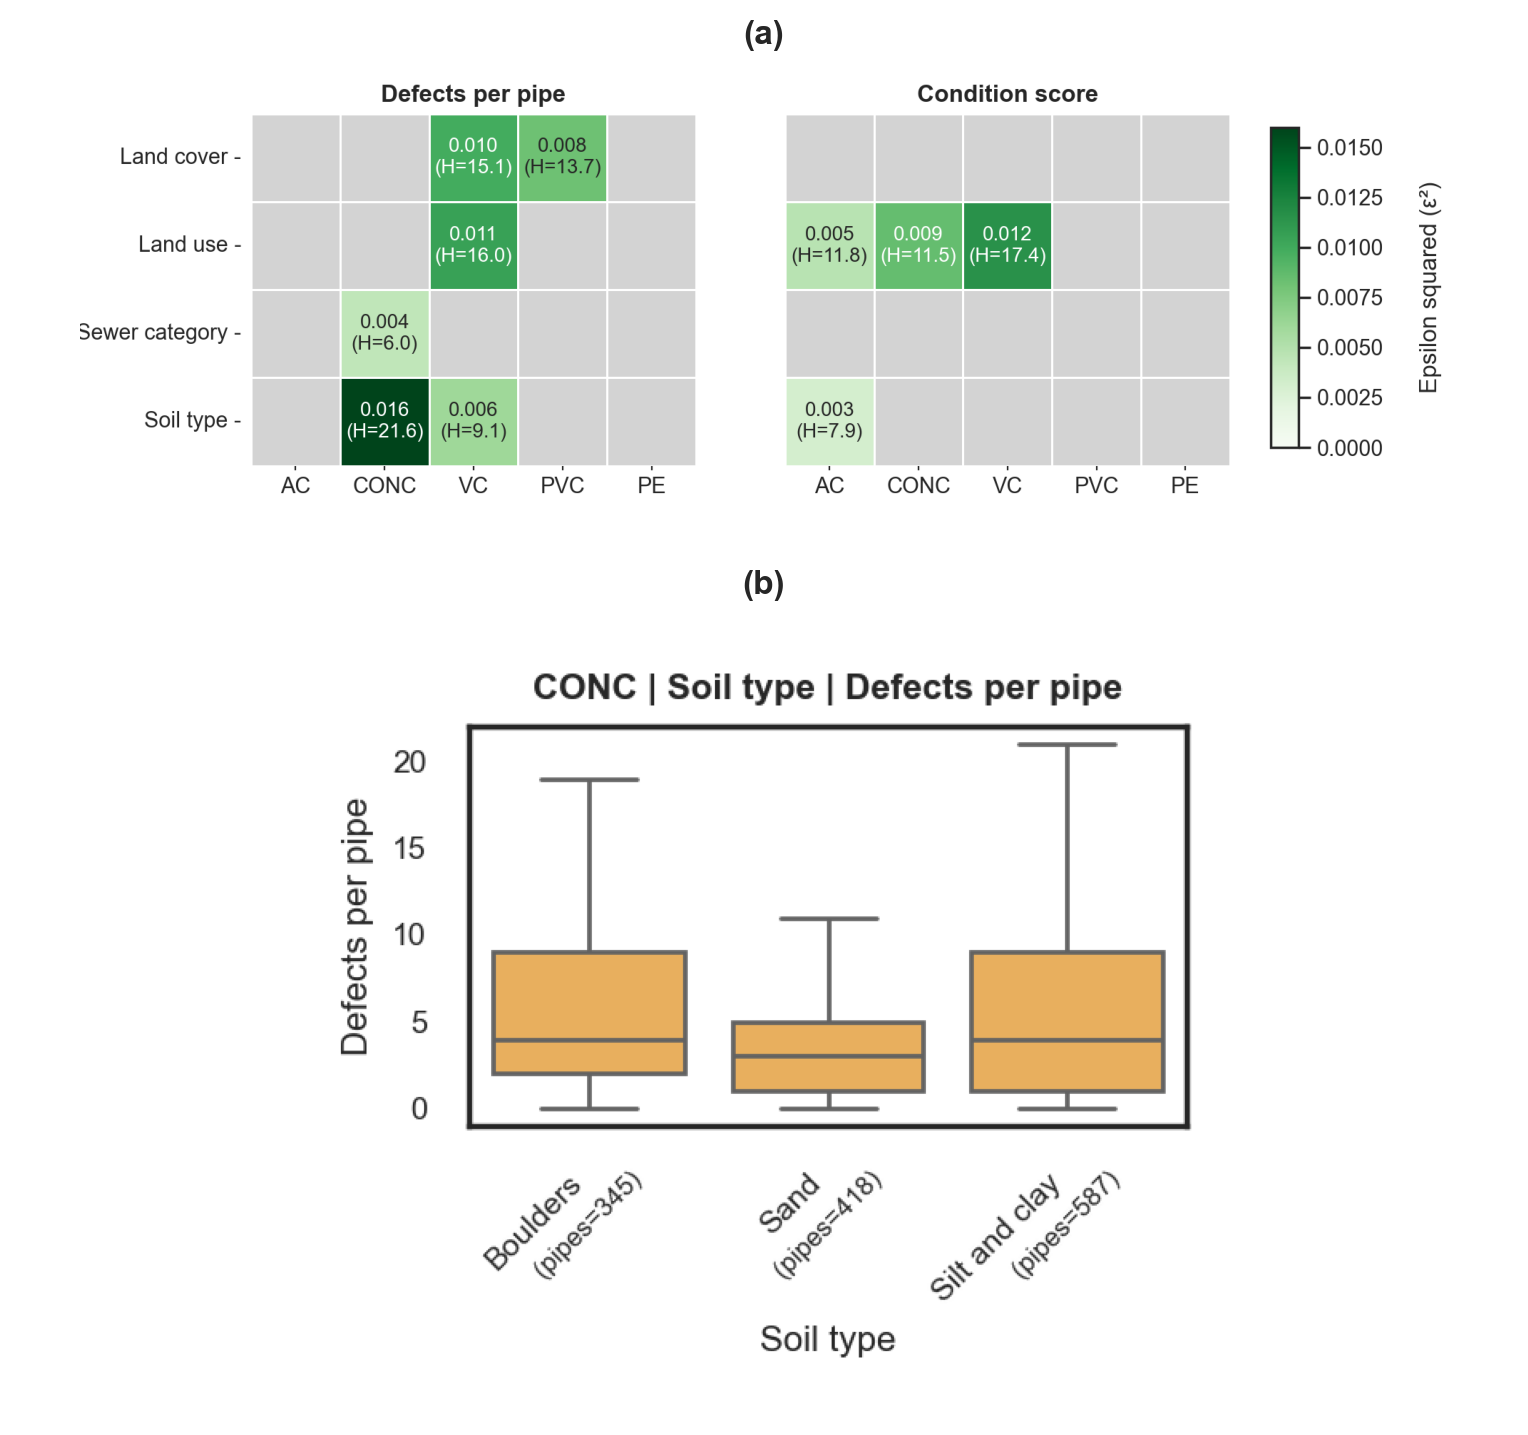

In [27]:
from Analysis_condition_metrics_categorical import plot_categorical_analysis_combined
fig_combined, df_pipes, epsilon_matrix = plot_categorical_analysis_combined(
    df_cctv_filtered=df_cctv_filtered,
    df_defect=df_defects,
    categorical_vars=factors_cat,
    metric_cols=["Defects_per_pipe", "Structural_condition_grade"],
    selected_materials=selected_materials,
    colors_materials=colors_material,
    min_epsilon2=0.012,
    display_names=display_names,
    metric_titles=["Defects per pipe", "Condition score"],
    analysis_kwargs={
        "condition": "Structural_condition_grade",
        "alpha": significant_p_threshold,
        "min_epsilon2": 0,
    },
)

# Save as PDF
fig_combined.savefig(
    "Figures/Figure 8.pdf",
    format="pdf",
    bbox_inches="tight"
)

## Relationships with defect types

In [28]:
from Analysis_defect_type_categorical import compute_nb_matrix_analysis, plot_nb_matrix_of_matrices

# Execute negative binomial model
results, relevant_defects, defect_order = compute_nb_matrix_analysis(df_defects=df_defects,
                                                                     df_cctv_filtered=df_cctv_filtered,
                                                                     selected_materials=selected_materials,
                                                                     factors_cat=factors_cat,
                                                                     get_categories_order=get_categories_order,
                                                                     pipe_id="Pipe_ID",
                                                                     defect_col="Defect_code_full",
                                                                     alpha=0.05,
                                                                     selected_defects=None,
                                                                     cov_type="HC0",
                                                                     max_clr=20,
                                                                     )


Material: AC

Factor: Land_cover_group
Valid categories:
  Vegetation: 228 pipes
  Urban: 2172 pipes
  Mixed: 102 pipes
Skipping omnibus model | Material=AC | Factor=Land_cover_group | Defect=Encrustation Deposits | null: Hessian inversion warning
Skipping omnibus model | Material=AC | Factor=Land_cover_group | Defect=Cracking Longitudinal | full: RuntimeWarning; null: RuntimeWarning


C:\Users\Juana\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Juana\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Skipping omnibus model | Material=AC | Factor=Land_cover_group | Defect=Cracking Multiple | full: did not converge, ConvergenceWarning, Hessian inversion warning; null: did not converge, ConvergenceWarning, Hessian inversion warning, RuntimeWarning, non-finite log-likelihood
Skipping omnibus model | Material=AC | Factor=Land_cover_group | Defect=Obstruction | full: RuntimeWarning; null: RuntimeWarning


C:\Users\Juana\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Juana\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Skipping omnibus model | Material=AC | Factor=Land_cover_group | Defect=Pipe Broken | null: did not converge, ConvergenceWarning, Hessian inversion warning, RuntimeWarning, non-finite log-likelihood


...

Omnibus model failed | Material=PE | Factor=Land_use_group | Defect=Pipe Holed | LinAlgError: Singular matrix
Skipping omnibus model | Material=PE | Factor=Land_use_group | Defect=Manhole Joint Faulty | full: did not converge, ConvergenceWarning, RuntimeWarning, non-finite log-likelihood
Skipping omnibus model | Material=PE | Factor=Land_use_group | Defect=Pipe Broken | full: Hessian inversion warning; null: Hessian inversion warning
Skipping cell | Material=PE | Factor=Land_use_group | Defect=Deformed Plastic Pipe | Category=Business | insufficient positive pipes (category=0, rest=16, required per group=1)

Factor: Sewer_category
Valid categories:
  Transmission: 29 pipes
  Local: 228 pipes
Skipping cell | Material=PE | Factor=Sewer_category | Defect=Joint Faulty | Category=Transmission | insufficient positive pipes (category=0, rest=15, required per group=1)
Skipping cell | Material=PE | Factor=Sewer_category | Defect=Joint Faulty | Category=Local | insufficient positive pipes (categ

C:\Users\Juana\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Juana\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Skipping omnibus model | Material=PE | Factor=Sewer_category | Defect=Infiltration Present | null: Hessian inversion warning
Skipping omnibus model | Material=PE | Factor=Sewer_category | Defect=Joint Open | null: RuntimeWarning
Skipping omnibus model | Material=PE | Factor=Sewer_category | Defect=Lateral Problem | full: Hessian inversion warning; null: Hessian inversion warning
Skipping omnibus model | Material=PE | Factor=Sewer_category | Defect=Cracking Longitudinal | null: Hessian inversion warning
Skipping omnibus model | Material=PE | Factor=Sewer_category | Defect=Cracking Multiple | full: Hessian inversion warning; null: Hessian inversion warning
Skipping cell | Material=PE | Factor=Sewer_category | Defect=Joint Displaced | Category=Transmission | insufficient positive pipes (category=0, rest=7, required per group=1)
Skipping cell | Material=PE | Factor=Sewer_category | Defect=Joint Displaced | Category=Local | insufficient positive pipes (category=7, rest=0, required per group

C:\Users\Juana\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Juana\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Skipping omnibus model | Material=PE | Factor=Soil_type | Defect=Joint Open | full: RuntimeWarning; null: did not converge, ConvergenceWarning, RuntimeWarning, non-finite log-likelihood
Skipping omnibus model | Material=PE | Factor=Soil_type | Defect=Lateral Problem | full: Hessian inversion warning; null: Hessian inversion warning
Skipping unstable IRR | Material=PE | Factor=Soil_type | Defect=Debris Silty | Category=Boulders | IRR=1.432 | 95% CI=[0.3201, 6.405] | CLR=20.01 > 20
Skipping omnibus model | Material=PE | Factor=Soil_type | Defect=Cracking Longitudinal | null: Hessian inversion warning
Skipping omnibus model | Material=PE | Factor=Soil_type | Defect=Cracking Multiple | full: Hessian inversion warning; null: Hessian inversion warning
Skipping cell | Material=PE | Factor=Soil_type | Defect=Joint Displaced | Category=Boulders | insufficient positive pipes (category=0, rest=6, required per group=1)
Skipping unstable IRR | Material=PE | Factor=Soil_type | Defect=Joint Displaced

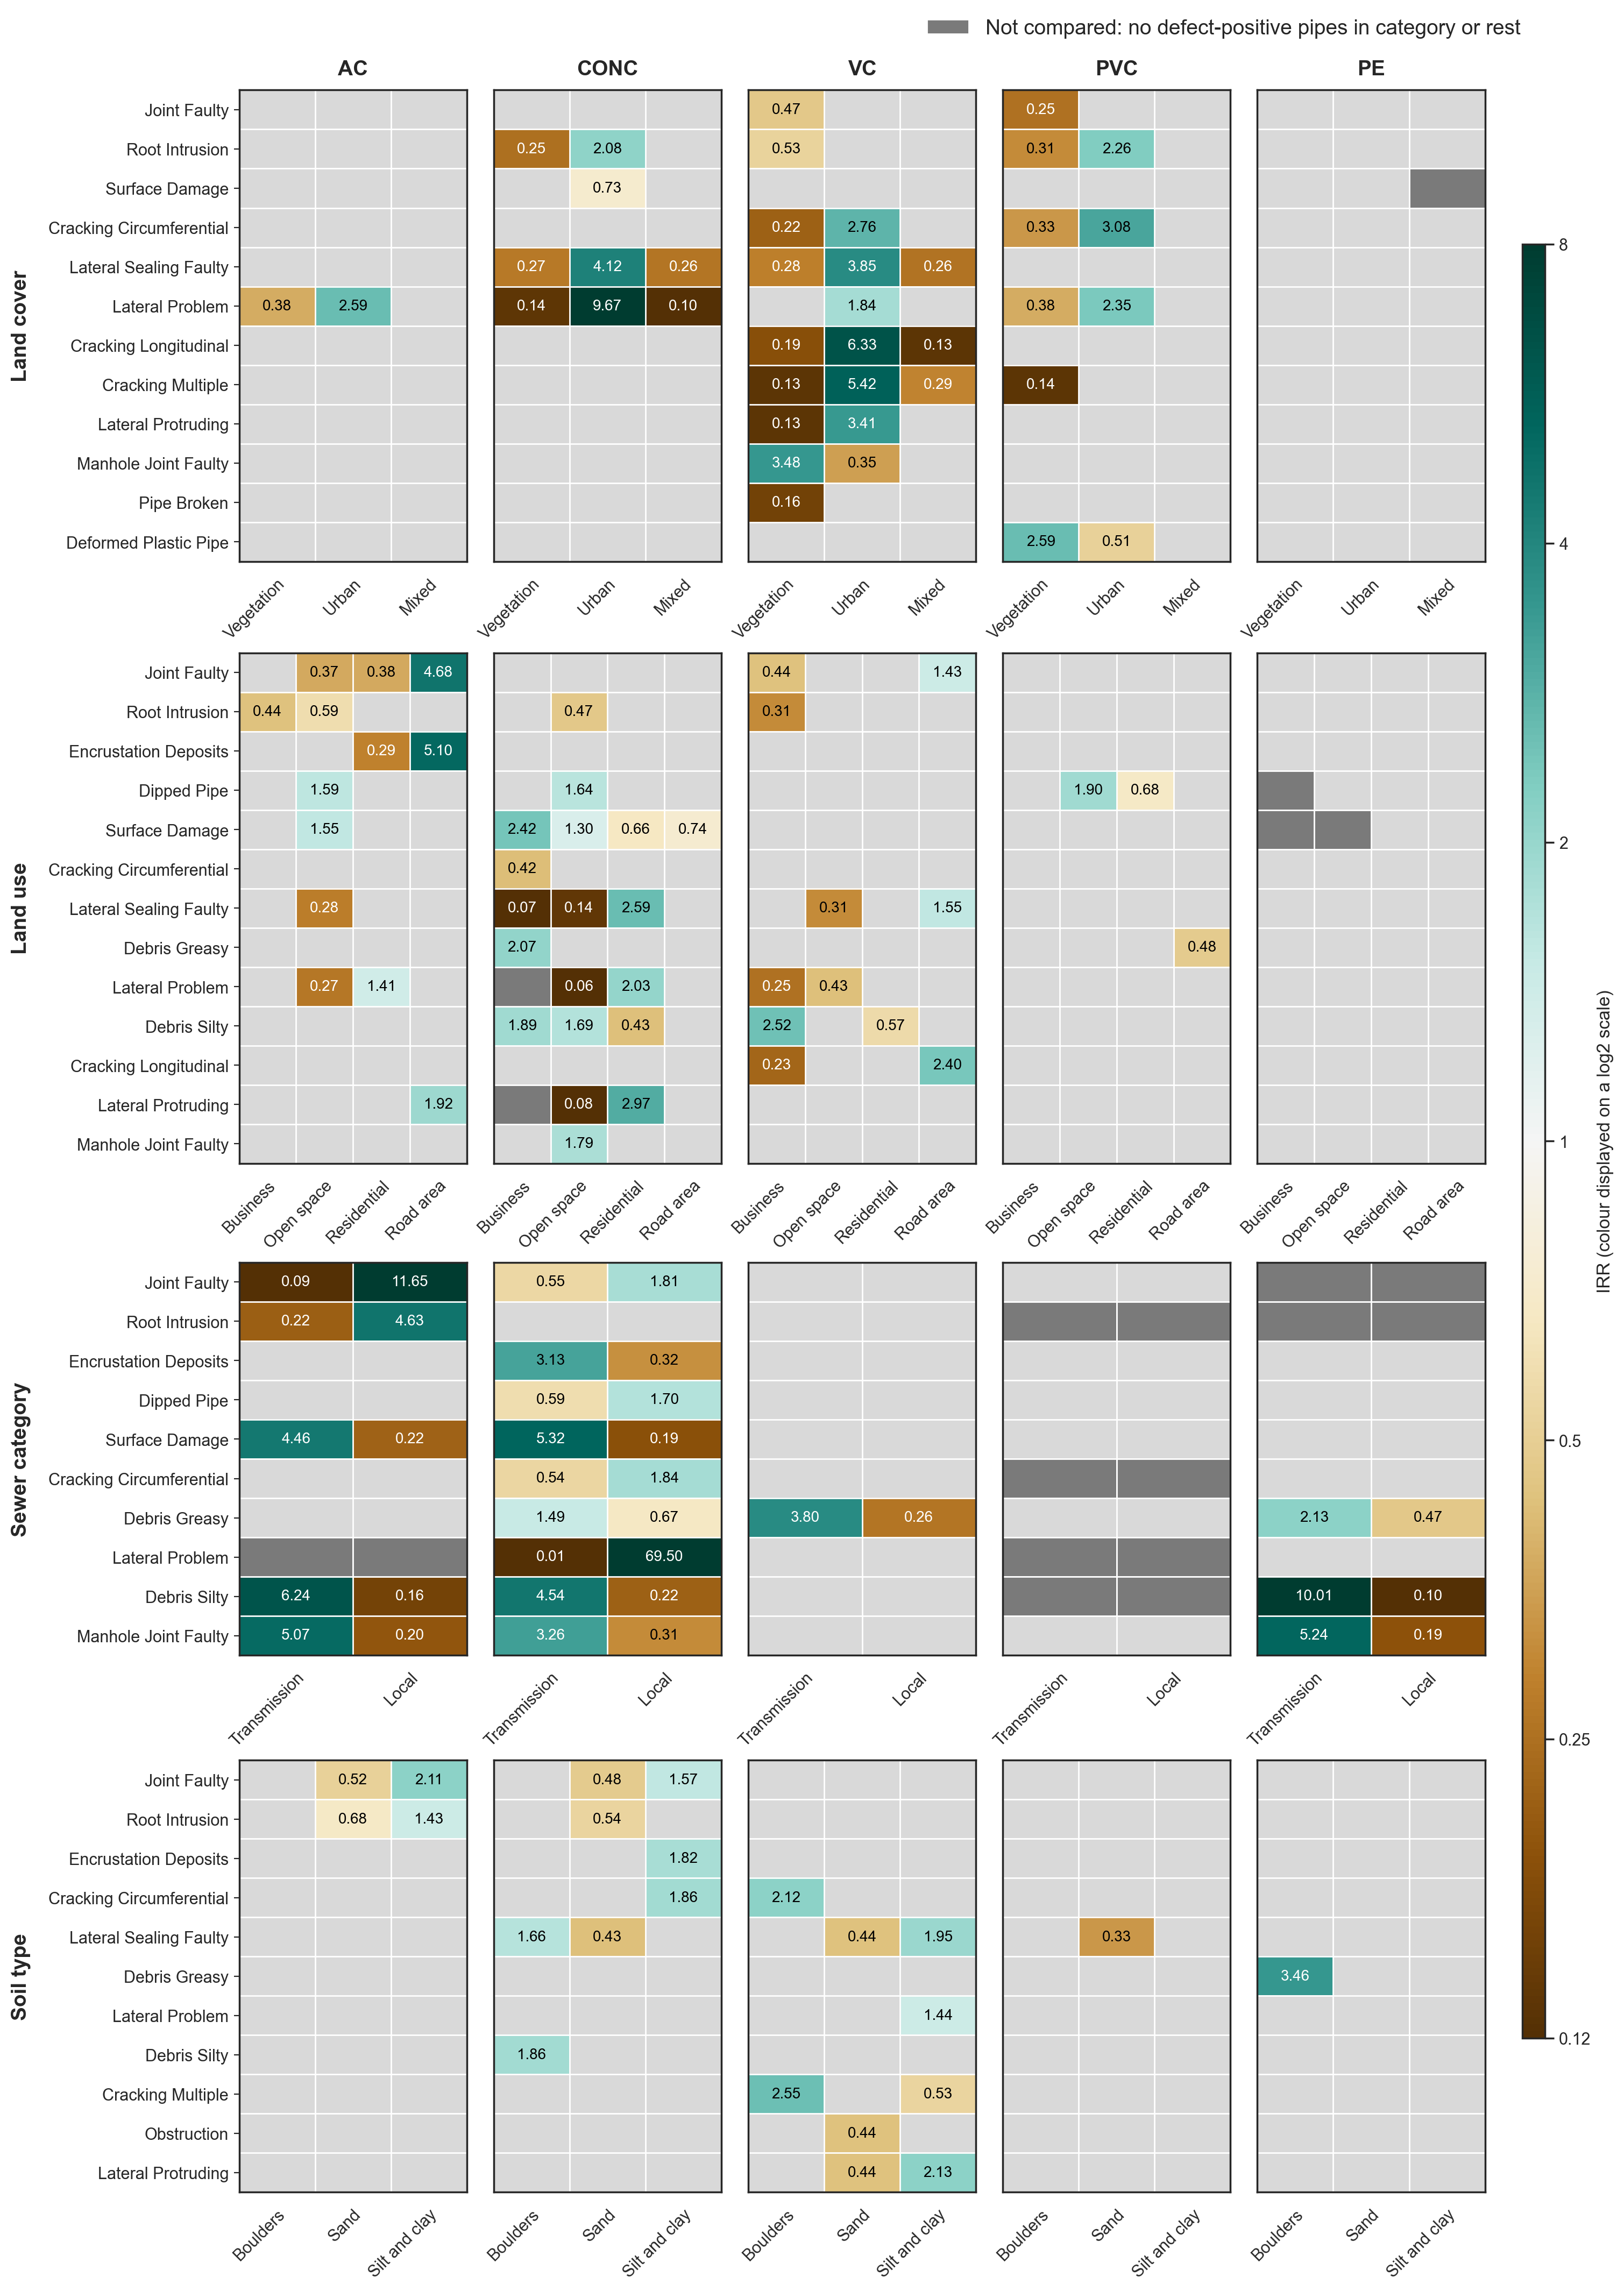

In [29]:
#Plot IRR from negative binomial model
fig_irr, axes = plot_nb_matrix_of_matrices(
    results=results,
    factors_cat=factors_cat,
    selected_materials=selected_materials,
    get_categories_order=get_categories_order,
    display_names=display_names,
    relevant_defects=relevant_defects,
    max_abs_log2=3,
)
fig_irr.savefig(
    "Figures/Figure 9.pdf",
    format="pdf",
    bbox_inches="tight"
)

fig.savefig(
    "Figures/Figure 8.pdf",
    format="pdf",
    bbox_inches="tight"
)